# FER IMPLEMENTATION — Condition 2: Data Augmentation

Ablation condition: **data-level intervention only**.

## Import modules

In [8]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import keras_tuner as kt
from tensorflow.keras.regularizers import l2

## Dataset paths

In [2]:
# Getting the path to the original train and test directories
train_dir = '/home/kamatsac/Desktop/Thesis/archive/train'
test_dir = '/home/kamatsac/Desktop/Thesis/archive/test'

## Class distribution

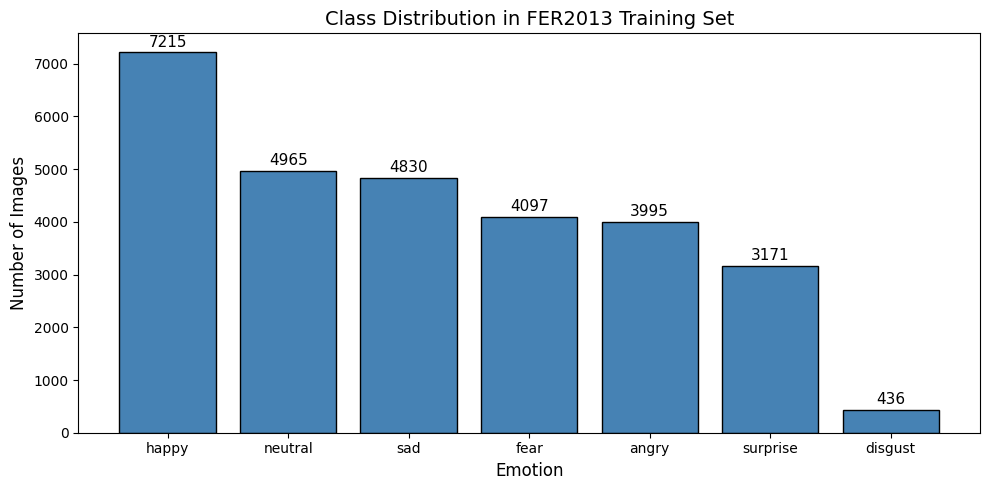

happy: 7215 images
neutral: 4965 images
sad: 4830 images
fear: 4097 images
angry: 3995 images
surprise: 3171 images
disgust: 436 images


In [3]:
classes = os.listdir(train_dir)
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=11)
plt.title('Class Distribution in FER2013 Training Set', fontsize=14)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.tight_layout()
plt.show()

for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

## Load frozen hyperparameters

These were tuned once on the baseline. They are not re-tuned here — that would confound the ablation.

In [4]:
import json
# Upload best_hp.json as a Kaggle dataset and update the path below
with open('/home/kamatsac/Desktop/Thesis/best_hp.json') as f:  # <-- update this path
    hp_values = json.load(f)

print('Loaded hyperparameters:')
print(f"  Dense units:   {hp_values['dense_units']}")
print(f"  Dropout rate:  {hp_values['dropout_rate']}")
print(f"  Learning rate: {hp_values['learning_rate']}")
print(f"  L2 regularization rate: {hp_values['l2_reg']}")

Loaded hyperparameters:
  Dense units:   256
  Dropout rate:  0.3
  Learning rate: 0.0001
  L2 regularization rate: 1e-05


## Preprocessing

**Key difference from baseline:** `train_datagen` adds augmentation transforms.  
`val_datagen` and `test_datagen` are unchanged — only `preprocess_input`, no augmentation.  

Augmentations chosen are standard for FER:
- `horizontal_flip`: faces are left-right symmetric
- `rotation_range=15`: small head-pose variation
- `width_shift_range / height_shift_range`: slight translation
- `zoom_range=0.1`: slight distance variation

No vertical flip or colour jitter — not realistic facial variation.

In [5]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16

# --- CHANGED FROM BASELINE: augmentation added to train_datagen only ---
# train_datagen = ImageDataGenerator(
#     preprocessing_function=preprocess_input,
#     validation_split=0.2,
#     horizontal_flip=True,
#     rotation_range=15,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.1,
# )

train_datagen = ImageDataGenerator(
    rotation_range=10,
    # shear_range=0.1,
    zoom_range=[0.85, 1.15],
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    width_shift_range = 0.05,        # Randomly shift the width of images by up to 10%
    height_shift_range = 0.05,       # Randomly shift the height of images by up to 10%
    horizontal_flip = True,         # Flip images horizontally at random
    preprocessing_function=preprocess_input,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)

# --- UNCHANGED from baseline ---
val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    subset='training',
    seed=42
)
validation_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    subset='validation',
    seed=42
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## Model architecture

Identical `build_model` function from baseline — not modified.

In [6]:
# Define model architecture here

def build_model(hp):
    # Tunable hyperparameters
    dense_units = hp.Choice('dense_units', values=[128, 256, 512])
    dropout_rate = hp.Float('dropout_rate', min_value=0.3, max_value=0.6, step=0.1)
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4, 1e-5])
    l2_reg = hp.Choice('l2_reg', values=[0.0, 1e-5, 1e-4, 1e-3])

    num_classes = 7

    # Base model
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    # Build model
    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Build model from frozen hyperparameters

In [9]:
# Fix all HPs to baseline-tuned values — no tuner search runs here
hp = kt.HyperParameters()
hp.Fixed('dense_units',   hp_values['dense_units'])
hp.Fixed('dropout_rate',  hp_values['dropout_rate'])
hp.Fixed('learning_rate', hp_values['learning_rate'])
hp.Fixed('l2_reg', hp_values['l2_reg'])

aug_model = build_model(hp)
aug_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Hyperparameter optimization

Identical to baseline — not modified.

In [10]:
checkpoint = ModelCheckpoint(
    'aug_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=False,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

## Model training

In [11]:
history = aug_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[checkpoint, early_stop, lr_scheduler]
)

/usr/local/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1782737025.788123  171056 service.cc:148] XLA service 0x7f9b100601b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782737025.788144  171056 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1782737025.788146  171056 service.cc:156]   StreamExecutor device (1): NVIDIA RTX A2000 12GB, Compute Capability 8.6
2026-06-29 14:43:45.917062: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782737026.743373  171056 cuda_dnn.cc:529] Loaded cuDNN version 91900


   3/1436 ━━━━━━━━━━━━━━━━━━━━ 1:43 72ms/step - accuracy: 0.1319 - loss: 2.7113 

I0000 00:00:1782737029.842225  171056 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 186/1436 ━━━━━━━━━━━━━━━━━━━━ 2:26 117ms/step - accuracy: 0.2089 - loss: 2.1194

2026-06-29 14:44:12.868812: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5260_0', 8 bytes spill stores, 8 bytes spill loads



1436/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.3074 - loss: 1.7934

2026-06-29 14:46:51.423750: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1734_0', 8 bytes spill stores, 8 bytes spill loads




Epoch 1: val_accuracy improved from -inf to 0.42257, saving model to aug_best_model.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 191s 128ms/step - accuracy: 0.3075 - loss: 1.7933 - val_accuracy: 0.4226 - val_loss: 1.4919 - learning_rate: 1.0000e-04
Epoch 2/50
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.4270 - loss: 1.5089
Epoch 2: val_accuracy improved from 0.42257 to 0.43424, saving model to aug_best_model.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 175s 122ms/step - accuracy: 0.4270 - loss: 1.5089 - val_accuracy: 0.4342 - val_loss: 1.4776 - learning_rate: 1.0000e-04
Epoch 3/50
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.4569 - loss: 1.4326
Epoch 3: val_accuracy improved from 0.43424 to 0.43581, saving model to aug_best_model.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 177s 123ms/step - accuracy: 0.4569 - loss: 1.4326 - val_accuracy: 0.4358 - val_loss: 1.4484 - learning_rate: 1.0000e-04
Epoch 4/50
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4689 - loss: 1.4165


### Save history

In [12]:
with open('aug_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

### Read history (use in a fresh session)

In [13]:
# with open('aug_history.pkl', 'rb') as f:
#     history_dict = pickle.load(f)

# class _HistoryProxy:
#     def __init__(self, d): self.history = d
# history = _HistoryProxy(history_dict)

## Result visualization

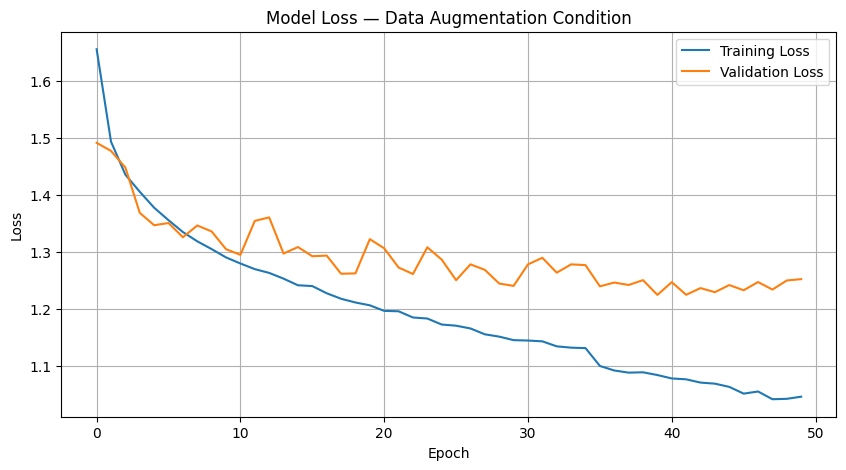

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss — Data Augmentation Condition')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

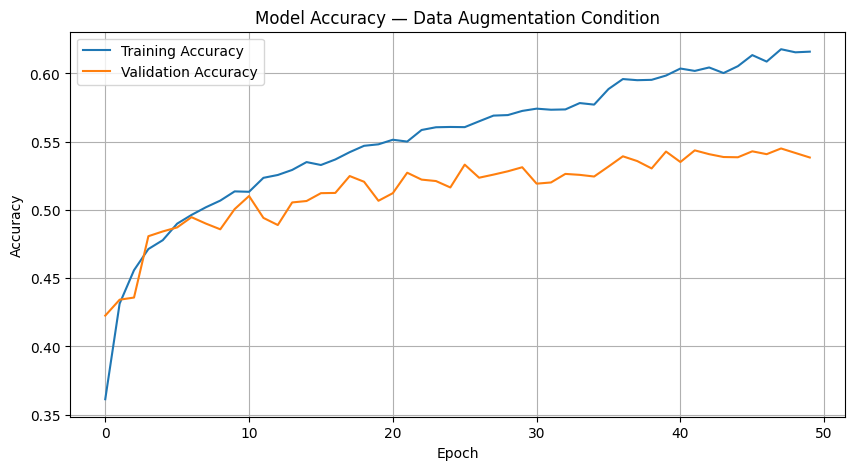

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy — Data Augmentation Condition')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Model evaluation

### Load saved model (use in a fresh session)

In [16]:
# aug_model = load_model('aug_best_model.keras')

In [17]:
loss, accuracy = aug_model.evaluate(test_generator)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

445/449 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4592 - loss: 1.4265

2026-06-29 17:09:22.666554: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1734_0', 8 bytes spill stores, 8 bytes spill loads



449/449 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.4602 - loss: 1.4243
Test Loss:     1.2300
Test Accuracy: 0.5458


In [18]:
predictions = aug_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

from sklearn.metrics import classification_report
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step
              precision    recall  f1-score   support

       angry       0.51      0.35      0.41       958
     disgust       0.88      0.14      0.23       111
        fear       0.49      0.25      0.33      1024
       happy       0.61      0.85      0.71      1774
     neutral       0.47      0.61      0.53      1233
         sad       0.45      0.48      0.46      1247
    surprise       0.79      0.55      0.65       831

    accuracy                           0.55      7178
   macro avg       0.60      0.46      0.48      7178
weighted avg       0.55      0.55      0.53      7178



Macro F1 Score: 0.4756


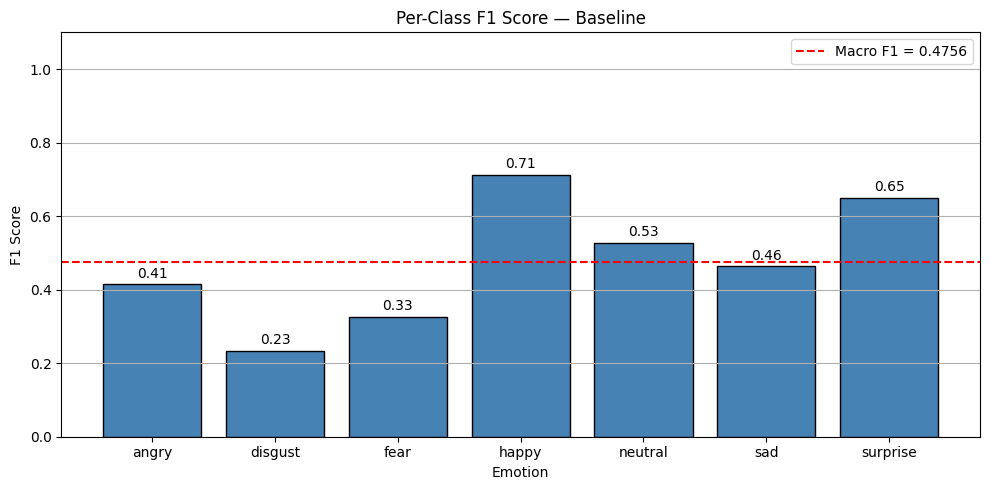

In [19]:

from sklearn.metrics import f1_score

# Macro F1 — single number summary
macro_f1 = f1_score(true_classes, predicted_classes, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

# Per-class F1 visualization
report = classification_report(
    true_classes, 
    predicted_classes,
    target_names=class_labels, 
    output_dict=True)

per_class_f1 = [report[cls]['f1-score'] for cls in class_labels]

plt.figure(figsize=(10, 5))
bars = plt.bar(class_labels, per_class_f1, color='steelblue', edgecolor='black')
plt.axhline(y=macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.4f}')
for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.title('Per-Class F1 Score — Baseline')
plt.xlabel('Emotion')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

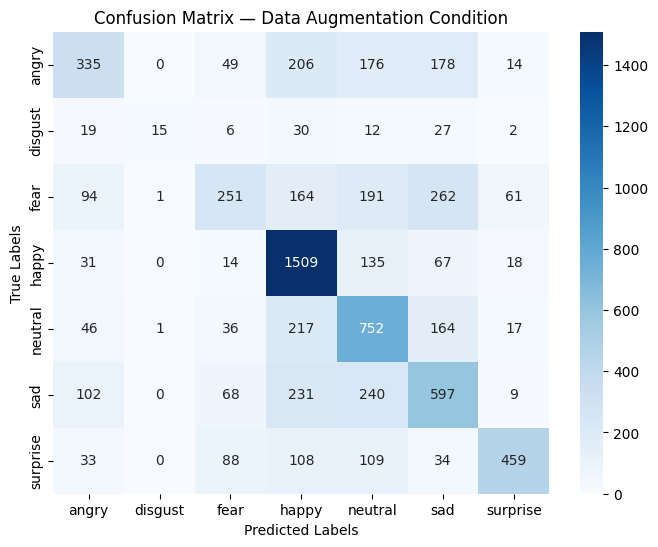

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix — Data Augmentation Condition')
plt.show()